In [1]:
from pathlib import Path
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from pytorch_lightning.core.lightning import LightningModule
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('/home/kai/DigitalICU/Experiments/HIRID-PatientStateSpace/')

from utils.config_dataset import *
from utils.ClassDataset import MergedDataset
from utils.ClassSOM import VASO_CLF, VASO_PHYSIO_PRED, SOM_MTL

RANDOMSEED = 2024
torch.manual_seed(RANDOMSEED)
np.random.seed(RANDOMSEED)

def mae_loss(x_, x, los=False):
    if los:
        loss = np.mean(np.abs(x - x_))
    else:
        mask_valid = np.where(x!=-1)
        loss = np.mean(np.abs(x[mask_valid] - x_[mask_valid]))
    return loss

In [14]:
model_path = "models/VASO_CLF/CNN-168hidden-8som-3r-0.1dropout-64-0.01/version_0"
model_file = os.path.join(model_path, "epoch161-val_loss0.02431.ckpt")
config_file = os.path.join(model_path, "model_config.p")

device = 'cuda'

 # load data
print("Loading dataset")
data_path = 'processed-merge/'
pid_valid = pickle.load(open(os.path.join(data_path, 'pid_valid_00.p'), 'rb'))
patient_info = pickle.load(open(os.path.join(data_path, 'patient_info.p'), 'rb'))
sample_dict = pickle.load(open(os.path.join(data_path, 'sample_dict_vasopressor.p'), 'rb'))
norm_params = pickle.load(open('processed-merge/norm_params_vasopressor.p', 'rb'))
norm_params_info = pickle.load(open('processed-merge/norm_params_info_vasopressor.p', 'rb'))

dischargestatus = []
for i in sample_dict:
    status = patient_info.loc[patient_info['patientid'] == sample_dict[i][1], 'discharge_status'].item()
    label = 1 if status == 'dead' else 0
    dischargestatus.append(label)
dischargestatus = np.array(dischargestatus)

selected_physio = ['HR', 'RR', 'SpO2', 'ABPd', 'ABPm', 'ABPs', 'ZVD']
selected_med = ['norepinephrine', 'epinephrine', 'dobutamine']
train_test_indices = pickle.load(open(os.path.join(data_path, 'train_test_split_vasopressor.p'), 'rb'))
sampleid_train, sampleid_test = train_test_indices['train'], train_test_indices['test']
sampleid_tr, sampleid_val = train_test_split(sampleid_train, test_size=0.2, random_state=RANDOMSEED,
                                   stratify=dischargestatus[sampleid_train])

dataset_val = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_val},
                              df_info=patient_info, norm=True, selected_physio=selected_physio,selected_med=selected_med)
dataset_test = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_test},
                              df_info=patient_info, norm=True, selected_physio=selected_physio,selected_med=selected_med)
loader_val = DataLoader(dataset_val, batch_size=16, shuffle=False, num_workers=32)
loader_test = DataLoader(dataset_test, batch_size=16, shuffle=False, num_workers=16)

# Train model
config = pickle.load(open(config_file, 'rb'))

model = VASO_CLF.load_from_checkpoint(checkpoint_path=model_file, config=config)
model.to(device)
model.eval()

X_reconstructed = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_ = model(X)
    X_reconstructed.append(X_.cpu().detach().numpy())

pickle.dump(X_reconstructed, open(os.path.join(model_path, 'test_reconstructed_data.p'), 'wb'))

X_reconstructed = np.concatenate(X_reconstructed, axis=0)

Loading dataset


/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
100%|████████████████████████████████████████████████| 2/2 [00:07<00:00,  3.60s/it]


In [15]:
X_reconstructed.shape

(798, 90, 7)

In [18]:
dataset_test[1]['data'].shape

(180, 7)

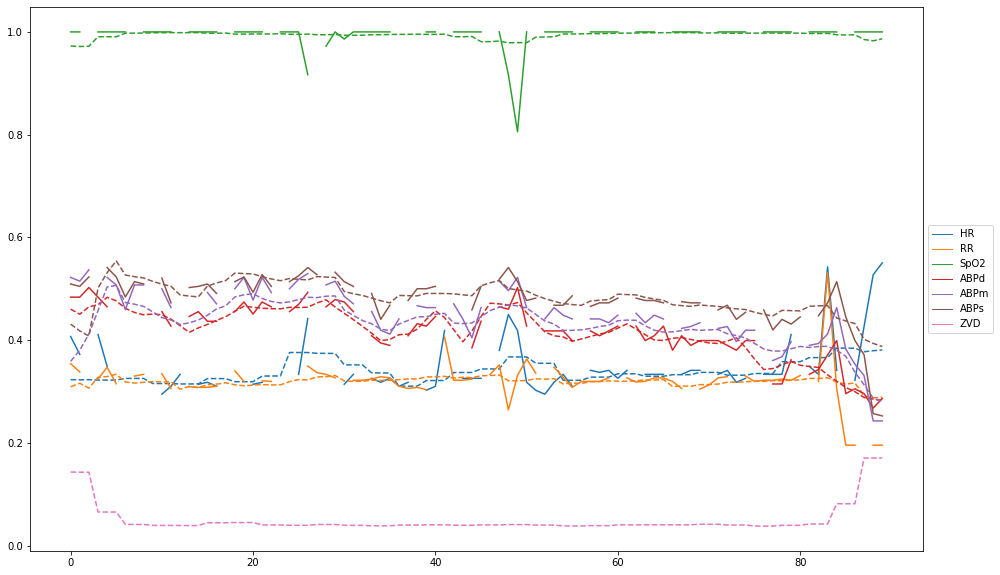

In [21]:
idx = 150

x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_ = X_reconstructed[idx]
x_[np.where(x_==-1)] = np.nan

labels = selected_physio

fig, ax = plt.subplots(1,1,figsize=(16,10))
colors = plt.cm.tab10
for j in range(7):
    ax.plot(range(90), x[:90,j], '-', color=colors(j))
    ax.plot(range(90), x_[:,j], '--', color=colors(j))
#     line = ax.plot(range(181), x[:, 10+j], '-', color=colors(j), label='groundtruth')
#     ax.plot(range(91,181), lstm_preds_mean[idx, :, j], '--', color=colors(j), label='LSTM')
#     ax.plot(range(91,181), guidedlstm_preds_mean[idx, :, j], '-.', color=colors(j), label='Guided LSTM')


lines = [Line2D([0], [0], color=colors(i), lw=1, label=labels[i]) for i in range(7)]
plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

In [1]:
import torch

In [55]:
print("allocated: %.2fG" % (torch.cuda.memory_allocated() / 1e9), "cached: %.2fG" % (torch.cuda.memory_cached() / 1e9))

allocated: 0.00G cached: 0.00G


/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/torch/cuda/memory.py:395: FutureWarning: torch.cuda.memory_cached has been renamed to torch.cuda.memory_reserved
  warnings.warn(


In [2]:
x = torch.normal(mean=0.0, std=0.05, size=(5,3))
z = torch.normal(mean=0.0, std=1, size=(2,3))

In [28]:
z[:,:,None].shape, z[:,:,None].repeat(1,1,5).shape

(torch.Size([2, 3, 1]), torch.Size([2, 3, 5]))

In [29]:
z[:,None,:].shape, z[:,None,:].repeat(1,5,1).shape

(torch.Size([2, 1, 3]), torch.Size([2, 5, 3]))

In [31]:
x

tensor([[-0.0300, -0.0205, -0.0679],
        [-0.0078,  0.1149, -0.0088],
        [-0.0166,  0.0453,  0.0070],
        [ 0.0532, -0.0222,  0.0042],
        [-0.0728,  0.0426,  0.0577]])

In [34]:
x[None,:,:].repeat(2,1,1)

tensor([[[-0.0300, -0.0205, -0.0679],
         [-0.0078,  0.1149, -0.0088],
         [-0.0166,  0.0453,  0.0070],
         [ 0.0532, -0.0222,  0.0042],
         [-0.0728,  0.0426,  0.0577]],

        [[-0.0300, -0.0205, -0.0679],
         [-0.0078,  0.1149, -0.0088],
         [-0.0166,  0.0453,  0.0070],
         [ 0.0532, -0.0222,  0.0042],
         [-0.0728,  0.0426,  0.0577]]])

In [35]:
z[:,None,:].repeat(1,5,1) - x[None,:,:].repeat(2,1,1)

tensor([[[ 0.7120,  0.7148, -0.7633],
         [ 0.6898,  0.5795, -0.8224],
         [ 0.6986,  0.6491, -0.8383],
         [ 0.6288,  0.7166, -0.8354],
         [ 0.7549,  0.6518, -0.8889]],

        [[-0.8268, -2.3010, -0.4700],
         [-0.8490, -2.4363, -0.5291],
         [-0.8402, -2.3667, -0.5450],
         [-0.9100, -2.2992, -0.5421],
         [-0.7840, -2.3640, -0.5956]]])

In [3]:
dist = (z[:,None,:].repeat(1,5,1) - x[None,:,:].repeat(2,1,1)).norm(dim=2)
dist

tensor([[0.8705, 0.8321, 0.8286, 0.8396, 0.8879],
        [1.5564, 1.4432, 1.5485, 1.5897, 1.4279]])

In [4]:
torch.argmin(dist, dim=1)

tensor([2, 4])

In [7]:
x[torch.argmin(dist, dim=1)]

tensor([[ 0.0940, -0.0277,  0.0009],
        [-0.0142, -0.1153,  0.0408]])

In [8]:
x

tensor([[-0.0069,  0.0278,  0.0519],
        [-0.0402, -0.0719, -0.0077],
        [ 0.0940, -0.0277,  0.0009],
        [-0.0222,  0.0795,  0.0242],
        [-0.0142, -0.1153,  0.0408]])